# **Child Well-being — MDS Country Projection**
**University: University of Milano-Bicocca**  
**Master's Degree: Data Science (A.Y. 2025/2026)**  
**Course: Data Science Lab**

---

**Goal**: project each OECD country into a 2D (or 3D) space using **Classical Multi-Dimensional Scaling** (cMDS / PCoA),  
starting from posetic **symmetric separation** between countries computed via Bubley-Dyer MCMC sampling.  
Countries with similar ranking behaviour end up close together; countries with very different profiles are far apart.

**Temporal comparison**: after independently computing MDS for 2015 and 2018, the two embeddings are  
aligned using **Procrustes analysis** (rotation + reflection, no scaling) so that arrows between the  
same country across years represent genuine positional shifts in the dominance space.

| Domain | 2015 dataset | 2018 dataset |
|--------|--------------|--------------|
| **Indicators** | `040_indicators_macro_dim_3_level_2015.parquet` | `040_indicators_macro_dim_3_level_2018.parquet` |
| **Public Expenditure** | `040_public_expenditure_dim_discrete_4_level_2015.parquet` | `040_public_expenditure_dim_discrete_4_level_2018.parquet` |

---

### Method: posetic Separation → cMDS → Procrustes

**Step 1 — Symmetric Separation dissimilarity**  
For a poset $P$ with $n$ elements, the symmetric separation between elements $i$ and $j$ is:
$$\text{Sep}(i,j) = \mathbb{E}_{\sigma \sim \text{LE}(P)}\bigl[|\sigma(i) - \sigma(j)|\bigr]$$
the expected absolute rank difference, averaged over all linear extensions via **Bubley-Dyer MCMC** (50 000 samples).  
Normalised to $[0,1]$ by dividing by $n-1$, this gives a smooth, Euclidean-like dissimilarity:
$$D(i,j) = \frac{\text{Sep}(i,j)}{n-1}$$
Pairs of countries that tend to receive similar ranks across all compatible total orders → small $D$;  
pairs that are typically far apart in rank (or are incomparable) → large $D$.

**Step 2 — Classical MDS**  
Double-centering of $D^2$ yields the Gram matrix $B$; its top eigenvectors give the 2D/3D coordinates.
$$B = -\frac{1}{2} H D^{(2)} H, \quad H = I - \frac{1}{n}\mathbf{1}\mathbf{1}^T$$

**Step 3 — Procrustes alignment**  
Both embeddings are centered and scaled to unit Frobenius norm, then the 2018 embedding is  
rotated/reflected to best match the 2015 embedding. Arrows then show genuine positional change.

In [12]:
import sys; sys.path.insert(0, '..')

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial import procrustes as scipy_procrustes

import poset as P

---
## 1. Load data & build POSets

In [13]:
DOMAINS = {
    "indicators": {
        2015: "../data/040_indicators_macro_dim_3_level_2015.parquet",
        2018: "../data/040_indicators_macro_dim_3_level_2018.parquet",
        "label": "Child Outcome Indicators (macro-dim, 3 levels)",
    },
    "expenditure": {
        2015: "../data/040_public_expenditure_dim_discrete_4_level_2015.parquet",
        2018: "../data/040_public_expenditure_dim_discrete_4_level_2018.parquet",
        "label": "Public Expenditure (4 levels)",
    },
}

results = {}
for domain, meta in DOMAINS.items():
    results[domain] = {}
    for year in (2015, 2018):
        df = pl.read_parquet(meta[year])
        # Exclude TIME_PERIOD explicitly: constant within each single-year file,
        # auto-detection picks it up as an integer indicator column otherwise.
        ind_cols = [c for c in df.columns if c not in ("REF_AREA", "TIME_PERIOD")]
        res = P.poset_from_polars(
            df, col1="REF_AREA", indicator_cols=ind_cols,
            higher_is_better=True, dominance_mode="certain_or_possible",
        )
        results[domain][year] = res
        print(f"[{domain} {year}]  {len(res['elements'])} countries | indicators: {ind_cols}")

# Reference element order (same 16 countries across all datasets)
COUNTRIES = results["indicators"][2015]["elements"]
print(f"\nCountries ({len(COUNTRIES)}): {COUNTRIES}")

[indicators 2015]  16 countries | indicators: ['material_protection', 'health_prevention', 'education_skills', 'social_wellbeing']
[indicators 2018]  16 countries | indicators: ['material_protection', 'health_prevention', 'education_skills', 'social_wellbeing']
[expenditure 2015]  16 countries | indicators: ['C2_housing_culture', 'C3_public_health', 'C4_education_childcare', 'C5_environment']
[expenditure 2018]  16 countries | indicators: ['C2_housing_culture', 'C3_public_health', 'C4_education_childcare', 'C5_environment']

Countries (16): ['SWE', 'LTU', 'LVA', 'EST', 'GBR', 'FRA', 'LUX', 'AUT', 'ESP', 'PRT', 'ITA', 'SVN', 'POL', 'CZE', 'SVK', 'HUN']


---
## 2. Core functions

In [14]:
def separation_dissimilarity(
    result: dict,
    ref_elements: list,
    n_samples: int = 50_000,
    seed: int = 42,
) -> np.ndarray:
    """
    Symmetric posetic separation dissimilarity matrix, reindexed to ref_elements order.

    D[i,j] = E[|rank(i) - rank(j)|] / (n - 1)  ∈ [0, 1]

    Averaged over linear extensions via Bubley-Dyer MCMC.
    """
    poset = result["poset_certain"]
    elements = result["elements"]
    n = poset.n

    gen = P.BuildBubleyDyerSeparationGenerator(poset, seed, "symmetric")
    sep_result = gen.update(n=n_samples)
    sym = sep_result["symmetric"]  # shape (n, n), raw expected |rank_i - rank_j|

    perm = [elements.index(e) for e in ref_elements]
    D = sym[np.ix_(perm, perm)] / (n - 1)
    np.fill_diagonal(D, 0.0)
    return (D + D.T) / 2  # enforce exact symmetry


def classical_mds(D: np.ndarray, n_components: int = 2) -> tuple:
    """
    Classical MDS (Principal Coordinate Analysis) via double-centering.

    Returns
    -------
    coords      : (n, n_components) float — embedding coordinates
    eigenvalues : (n,) float — all eigenvalues, descending
    explained   : (n_components,) float — variance explained per component
                  (fraction of total positive eigenvalue sum)
    """
    n = D.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * (H @ (D ** 2) @ H)
    B = (B + B.T) / 2

    vals, vecs = np.linalg.eigh(B)
    idx = np.argsort(vals)[::-1]
    vals, vecs = vals[idx], vecs[:, idx]

    pos_sum = max(vals[vals > 0].sum(), 1e-12)
    explained = vals[:n_components] / pos_sum
    coords = vecs[:, :n_components] * np.sqrt(np.maximum(vals[:n_components], 0))
    return coords, vals, explained


def mds_stress(D: np.ndarray, coords: np.ndarray) -> float:
    """Kruskal stress-1: sqrt(sum((D - D_hat)^2) / sum(D^2))."""
    D_hat = np.sqrt(((coords[:, None, :] - coords[None, :, :]) ** 2).sum(axis=2))
    return float(np.sqrt(np.sum((D - D_hat) ** 2) / np.sum(D ** 2)))


print("Functions defined.")

Functions defined.


---
## 3. Compute MDS embeddings & Procrustes alignment

In [15]:
N_SAMPLES = 50_000   # Bubley-Dyer samples per poset

mds = {}  # mds[domain][year]["2d" | "3d" | "D" | "explained" | "stress"]

for domain, meta in DOMAINS.items():
    mds[domain] = {}
    for year in (2015, 2018):
        print(f"[{domain} {year}]  computing separation ({N_SAMPLES:,} samples)...", end=" ", flush=True)
        D = separation_dissimilarity(results[domain][year], COUNTRIES, n_samples=N_SAMPLES)
        coords2d, vals, expl2d = classical_mds(D, n_components=2)
        coords3d, _,    _      = classical_mds(D, n_components=3)
        stress = mds_stress(D, coords2d)
        mds[domain][year] = {
            "D": D, "2d": coords2d, "3d": coords3d,
            "explained": expl2d, "stress": stress, "eigenvalues": vals,
        }
        print(f"explained: {expl2d[0]*100:.1f}% + {expl2d[1]*100:.1f}% = {expl2d.sum()*100:.1f}% | "
              f"stress-1: {stress:.3f}")

# Procrustes alignment: rotate/reflect 2018 onto 2015 reference
# scipy_procrustes also centers + normalizes both → comparable arrow lengths
aligned = {}
for domain in DOMAINS:
    X15_2d, X18_2d, disp2d = scipy_procrustes(mds[domain][2015]["2d"], mds[domain][2018]["2d"])
    X15_3d, X18_3d, disp3d = scipy_procrustes(mds[domain][2015]["3d"], mds[domain][2018]["3d"])
    aligned[domain] = {
        "2d": (X15_2d, X18_2d, disp2d),
        "3d": (X15_3d, X18_3d, disp3d),
    }
    print(f"\n[{domain}] Procrustes disparity  2D: {disp2d:.4f}  3D: {disp3d:.4f}")
    print(f"  → higher disparity = larger structural shift between years")

[indicators 2015]  computing separation (50,000 samples)... explained: 83.0% + 4.5% = 87.5% | stress-1: 0.133
[indicators 2018]  computing separation (50,000 samples)... explained: 78.7% + 5.0% = 83.6% | stress-1: 0.167
[expenditure 2015]  computing separation (50,000 samples)... explained: 61.9% + 6.4% = 68.3% | stress-1: 0.276
[expenditure 2018]  computing separation (50,000 samples)... explained: 76.0% + 6.0% = 82.0% | stress-1: 0.190

[indicators] Procrustes disparity  2D: 0.9097  3D: 0.9093
  → higher disparity = larger structural shift between years

[expenditure] Procrustes disparity  2D: 0.4848  3D: 0.4745
  → higher disparity = larger structural shift between years


---
## 4. 2D movement maps

Arrows connect each country's **2015** position (circle, blue) to its **2018** position (diamond, red)  
in the Procrustes-aligned MDS space.  
Longer arrows = larger shift in the dominance structure between the two years.

---
### 4.1 Indicators

In [ ]:
def plot_movement_2d(
    X15: np.ndarray,
    X18: np.ndarray,
    labels: list,
    title: str,
    expl: np.ndarray = None,
    disparity: float = None,
    figsize: tuple = (12, 9),
    color_15: str = "#2980b9",
    color_18: str = "#c0392b",
):
    fig, ax = plt.subplots(figsize=figsize)
    ax.axhline(0, color="#dee2e6", lw=0.8, zorder=0)
    ax.axvline(0, color="#dee2e6", lw=0.8, zorder=0)

    displacements = np.sqrt(((X18 - X15) ** 2).sum(axis=1))
    max_disp = displacements.max() if displacements.max() > 0 else 1

    # Arrows: color intensity proportional to displacement magnitude
    cmap = plt.colormaps["RdYlGn_r"]
    for i in range(len(labels)):
        arrow_col = cmap(displacements[i] / max_disp)
        ax.annotate(
            "",
            xy=X18[i], xytext=X15[i],
            arrowprops=dict(
                arrowstyle="-|>",
                color=arrow_col,
                lw=1.8,
                mutation_scale=12,
            ),
            zorder=3,
        )

    # 2015 points
    ax.scatter(X15[:, 0], X15[:, 1], c=color_15, s=160, zorder=5, label="2015",
               edgecolors="white", linewidths=1.5, marker="o")
    # 2018 points
    ax.scatter(X18[:, 0], X18[:, 1], c=color_18, s=160, zorder=5, label="2018",
               edgecolors="white", linewidths=1.5, marker="D")

    # Country labels (only at 2015 position to avoid clutter)
    for i, lbl in enumerate(labels):
        ax.annotate(lbl, X15[i], fontsize=8, color="#1a5276",
                    xytext=(5, 5), textcoords="offset points", zorder=6)

    # Axis labels
    dim1_label = f"MDS dim 1 ({expl[0]*100:.1f}%)" if expl is not None else "MDS dim 1"
    dim2_label = f"MDS dim 2 ({expl[1]*100:.1f}%)" if expl is not None else "MDS dim 2"
    ax.set_xlabel(dim1_label, fontsize=10)
    ax.set_ylabel(dim2_label, fontsize=10)

    subtitle = f"Procrustes disparity: {disparity:.4f}" if disparity is not None else ""
    ax.set_title(f"{title}\n{subtitle}", fontsize=12, fontweight="bold")

    # Colorbar for displacement intensity
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, max_disp))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.6, aspect=20, pad=0.02)
    cbar.set_label("Displacement magnitude", fontsize=9)

    ax.legend(loc="best", fontsize=10)
    ax.grid(True, alpha=0.15)
    plt.tight_layout()
    plt.show()
    return fig, ax


domain = "indicators"
X15, X18, disp = aligned[domain]["2d"]
expl_avg = (mds[domain][2015]["explained"] + mds[domain][2018]["explained"]) / 2

plot_movement_2d(
    X15, X18, COUNTRIES,
    title=f"Country trajectories — {DOMAINS[domain]['label']}",
    expl=expl_avg,
    disparity=disp,
)

### 4.2 Public Expenditure

/var/folders/zb/s5bg_j794dd0zl1hvkwlj1m80000gn/T/ipykernel_79120/2724480620.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("RdYlGn_r")


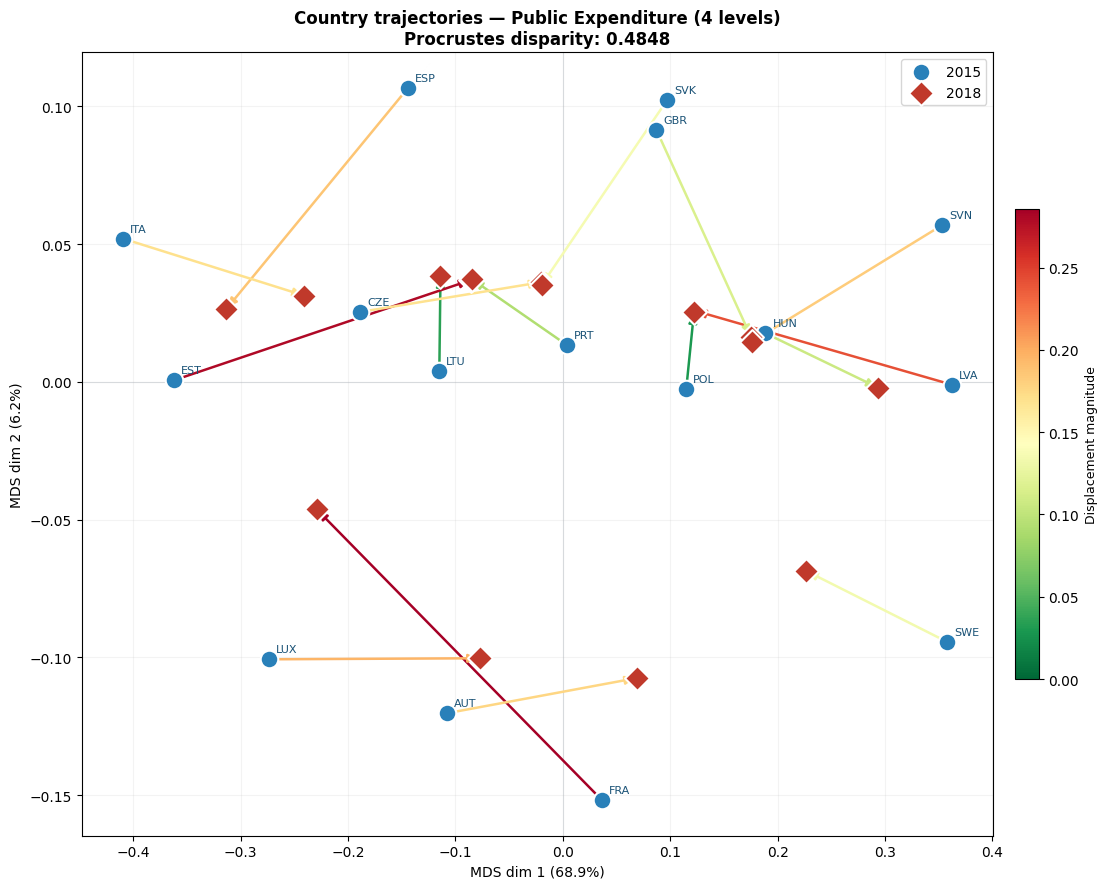

(<Figure size 1200x900 with 2 Axes>,
 <Axes: title={'center': 'Country trajectories — Public Expenditure (4 levels)\nProcrustes disparity: 0.4848'}, xlabel='MDS dim 1 (68.9%)', ylabel='MDS dim 2 (6.2%)'>)

In [23]:
domain = "expenditure"
X15, X18, disp = aligned[domain]["2d"]
expl_avg = (mds[domain][2015]["explained"] + mds[domain][2018]["explained"]) / 2

plot_movement_2d(
    X15, X18, COUNTRIES,
    title=f"Country trajectories — {DOMAINS[domain]['label']}",
    expl=expl_avg,
    disparity=disp,
)

---
## 5. 3D visualization

The third MDS dimension often captures residual structure lost in 2D.  
Segments connect each country's 2015 (sphere) to its 2018 (cube) position.

---
### 5.1 Indicators

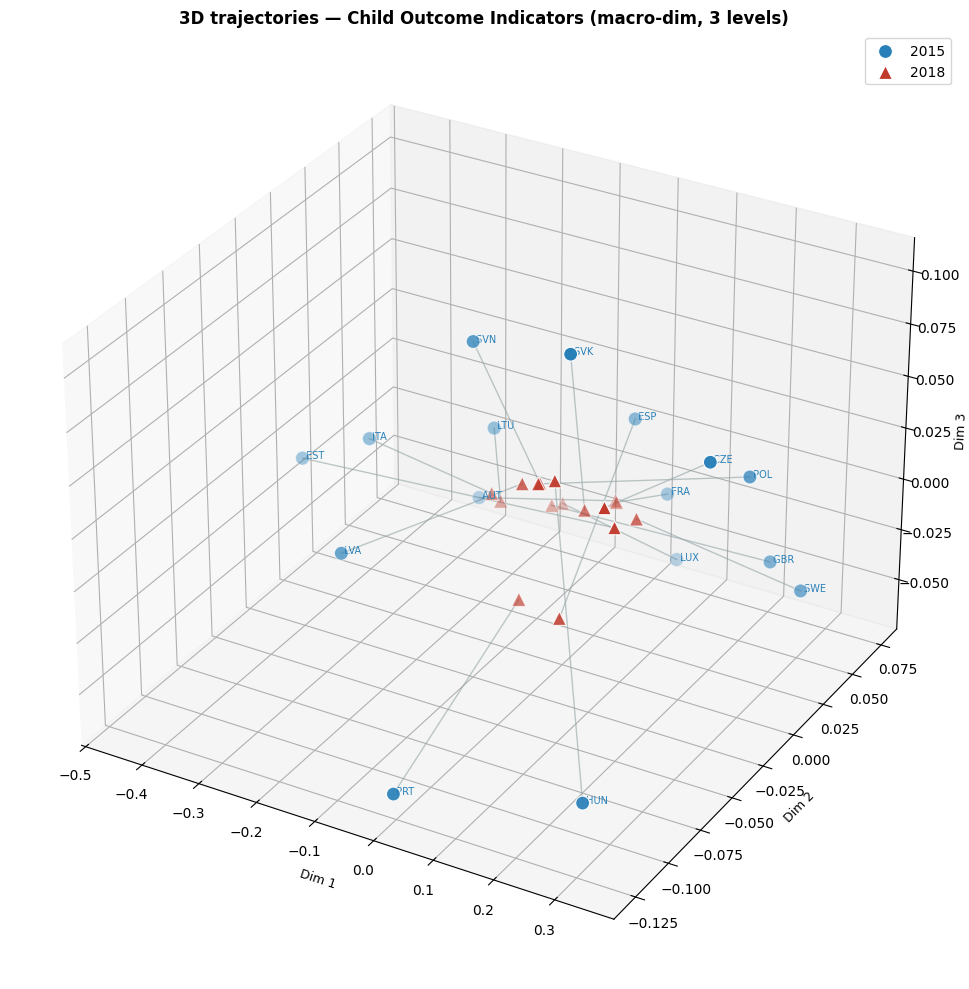

(<Figure size 1300x1000 with 1 Axes>,
 <Axes3D: title={'center': '3D trajectories — Child Outcome Indicators (macro-dim, 3 levels)'}, xlabel='Dim 1', ylabel='Dim 2', zlabel='Dim 3'>)

In [18]:
def plot_movement_3d(
    X15: np.ndarray,
    X18: np.ndarray,
    labels: list,
    title: str,
    figsize: tuple = (13, 10),
    color_15: str = "#2980b9",
    color_18: str = "#c0392b",
):
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")

    # Connecting segments 2015 → 2018
    for i in range(len(labels)):
        ax.plot(
            [X15[i, 0], X18[i, 0]],
            [X15[i, 1], X18[i, 1]],
            [X15[i, 2], X18[i, 2]],
            c="#95a5a6", lw=1.0, alpha=0.6,
        )

    ax.scatter(X15[:, 0], X15[:, 1], X15[:, 2],
               c=color_15, s=100, label="2015", depthshade=True,
               edgecolors="white", linewidths=0.8)
    ax.scatter(X18[:, 0], X18[:, 1], X18[:, 2],
               c=color_18, s=100, label="2018", marker="^", depthshade=True,
               edgecolors="white", linewidths=0.8)

    for i, lbl in enumerate(labels):
        ax.text(X15[i, 0], X15[i, 1], X15[i, 2], f" {lbl}", fontsize=7, color=color_15)

    ax.set_xlabel("Dim 1", fontsize=9)
    ax.set_ylabel("Dim 2", fontsize=9)
    ax.set_zlabel("Dim 3", fontsize=9)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()
    return fig, ax


domain = "indicators"
X15_3d, X18_3d, _ = aligned[domain]["3d"]
plot_movement_3d(
    X15_3d, X18_3d, COUNTRIES,
    title=f"3D trajectories — {DOMAINS[domain]['label']}",
)

### 5.2 Public Expenditure

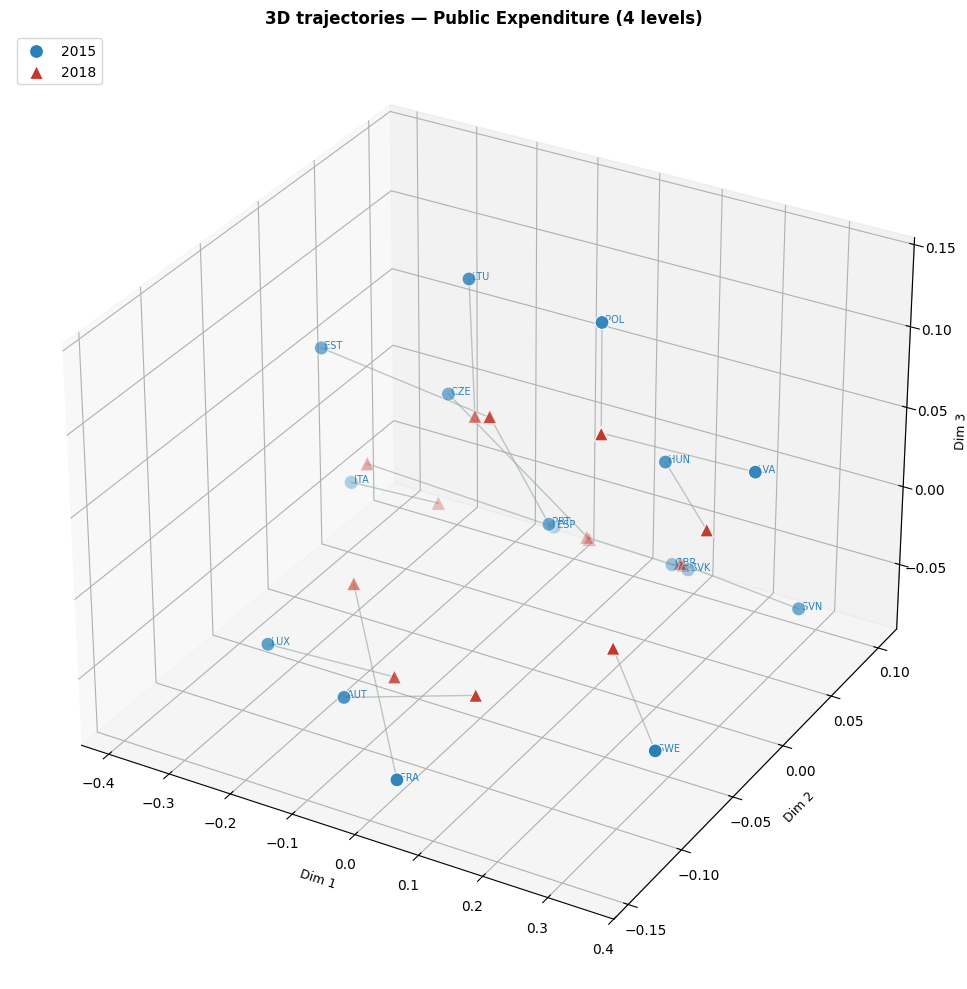

(<Figure size 1300x1000 with 1 Axes>,
 <Axes3D: title={'center': '3D trajectories — Public Expenditure (4 levels)'}, xlabel='Dim 1', ylabel='Dim 2', zlabel='Dim 3'>)

In [19]:
domain = "expenditure"
X15_3d, X18_3d, _ = aligned[domain]["3d"]
plot_movement_3d(
    X15_3d, X18_3d, COUNTRIES,
    title=f"3D trajectories — {DOMAINS[domain]['label']}",
)

---
## 6. Summary — displacement magnitudes

How much did each country move in the Procrustes-aligned MDS space?  
A large displacement means the country's relative position in the dominance structure changed significantly.

In [20]:
import polars as pl

pl.Config.set_tbl_rows(-1)
pl.Config.set_tbl_cols(-1)

summary_rows = []
for domain in DOMAINS:
    X15, X18, disp = aligned[domain]["2d"]
    displacements = np.sqrt(((X18 - X15) ** 2).sum(axis=1))
    for i, country in enumerate(COUNTRIES):
        summary_rows.append({
            "country": country,
            "domain": domain,
            "displacement": round(float(displacements[i]), 4),
        })

summary_df = pl.DataFrame(summary_rows)
display(summary_df.sort(["domain", "displacement"], descending=[False, True]))

country,domain,displacement
str,str,f64
"""FRA""","""expenditure""",0.2857
"""EST""","""expenditure""",0.2794
"""LVA""","""expenditure""",0.2412
"""LUX""","""expenditure""",0.1962
"""ESP""","""expenditure""",0.1873
"""SVN""","""expenditure""",0.182
"""AUT""","""expenditure""",0.1773
"""ITA""","""expenditure""",0.1702
"""CZE""","""expenditure""",0.1686


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

cmap_bars = plt.colormaps["RdYlGn_r"]

for ax, domain in zip(axes, DOMAINS):
    X15, X18, _ = aligned[domain]["2d"]
    displacements = np.sqrt(((X18 - X15) ** 2).sum(axis=1))
    order = np.argsort(displacements)[::-1]
    countries_sorted = [COUNTRIES[i] for i in order]
    disps_sorted = displacements[order]
    max_d = disps_sorted.max()

    bar_colors = [cmap_bars(d / max_d) for d in disps_sorted]
    bars = ax.bar(countries_sorted, disps_sorted, color=bar_colors, edgecolor="white", linewidth=0.8)

    ax.set_title(f"{DOMAINS[domain]['label']}", fontsize=11, fontweight="bold")
    ax.set_ylabel("Displacement (Procrustes space)", fontsize=9)
    ax.tick_params(axis="x", rotation=40, labelsize=8)
    ax.grid(axis="y", alpha=0.2)

    # Annotate values on bars
    for bar, val in zip(bars, disps_sorted):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max_d * 0.01,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=7, color="#2c3e50",
        )

fig.suptitle("Country displacement 2015 → 2018 in MDS dominance space",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Scree plots — eigenvalue explained variance

How many dimensions are needed to faithfully represent the dominance structure?  
The elbow in the scree plot indicates the optimal number of MDS components.

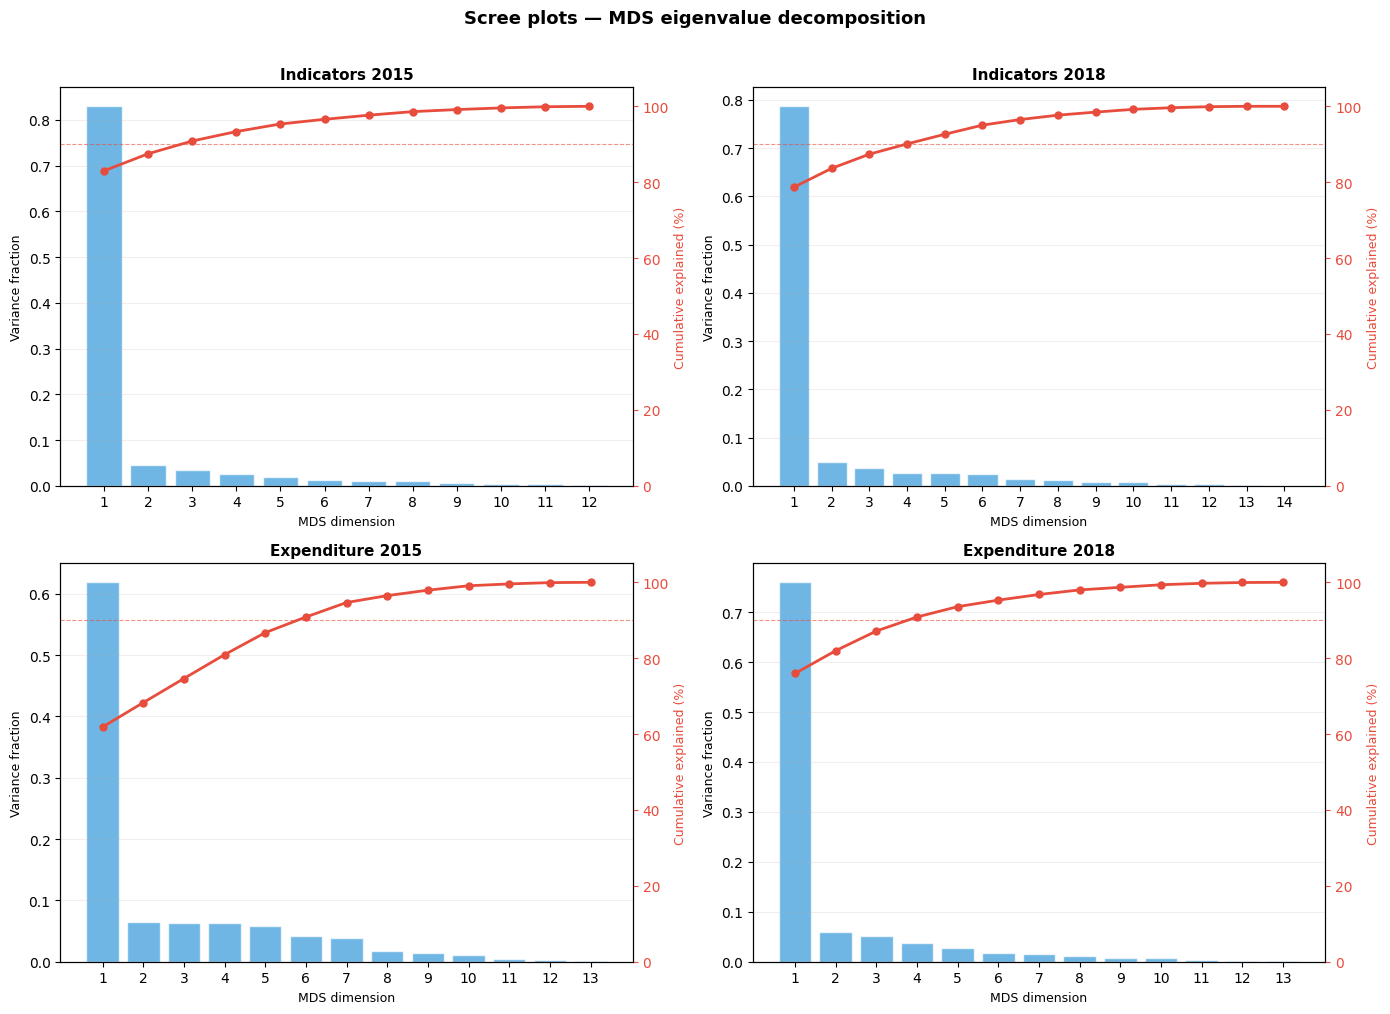

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, domain in enumerate(DOMAINS):
    for col, year in enumerate((2015, 2018)):
        ax = axes[row, col]
        vals = mds[domain][year]["eigenvalues"]
        pos_vals = vals[vals > 0]
        explained_cumulative = np.cumsum(pos_vals) / pos_vals.sum()
        dims = np.arange(1, len(pos_vals) + 1)

        ax.bar(dims, pos_vals / pos_vals.sum(),
               color="#3498db", alpha=0.7, edgecolor="white", label="Individual")
        ax2 = ax.twinx()
        ax2.plot(dims, explained_cumulative * 100, "o-",
                 color="#e74c3c", lw=2, ms=5, label="Cumulative %")
        ax2.axhline(90, color="#e74c3c", lw=0.8, ls="--", alpha=0.6)
        ax2.set_ylabel("Cumulative explained (%)", fontsize=9, color="#e74c3c")
        ax2.tick_params(axis="y", colors="#e74c3c")
        ax2.set_ylim(0, 105)

        ax.set_xlabel("MDS dimension", fontsize=9)
        ax.set_ylabel("Variance fraction", fontsize=9)
        ax.set_title(f"{domain.capitalize()} {year}", fontsize=11, fontweight="bold")
        ax.set_xticks(dims)
        ax.grid(axis="y", alpha=0.2)

fig.suptitle("Scree plots — MDS eigenvalue decomposition",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

*This notebook is licensed under [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).*